In [32]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


In [33]:
descriptors_df_train = pd.read_pickle('data/descriptors_df_train.pkl')
descriptors_df_test = pd.read_pickle('data/descriptors_test.pkl')

#fill nans with mean
descriptors_df_train.fillna(descriptors_df_train.mean(), inplace=True)
descriptors_df_test.fillna(descriptors_df_test.mean(), inplace=True)

--- Starting Feature Importance Analysis ---
Loading training and testing data...
Training BalancedRandomForestClassifier on the full training set...
Model ROC AUC on test set: 0.9832

Top 50 Most Important Features:
                        feature  importance
102              mca_mca_cau_q6    0.058458
98               mca_mca_cau_q2    0.057508
101              mca_mca_cau_q5    0.053386
100              mca_mca_cau_q4    0.049069
99               mca_mca_cau_q3    0.046193
96               mca_mca_cau_q0    0.043286
103              mbe_mbe_eff_q0    0.041834
107              mbe_mbe_eff_q4    0.041631
104              mbe_mbe_eff_q1    0.041105
106              mbe_mbe_eff_q3    0.037430
97               mca_mca_cau_q1    0.034620
108              mbe_mbe_eff_q5    0.033634
105              mbe_mbe_eff_q2    0.032933
109              mbe_mbe_eff_q6    0.031788
3                  copula_tau_2    0.013176
63                     m_cau_q0    0.011470
64                     m_cau_q1    

/tmp/ipykernel_3463/3448741815.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Plot saved to feature_importance.pdf


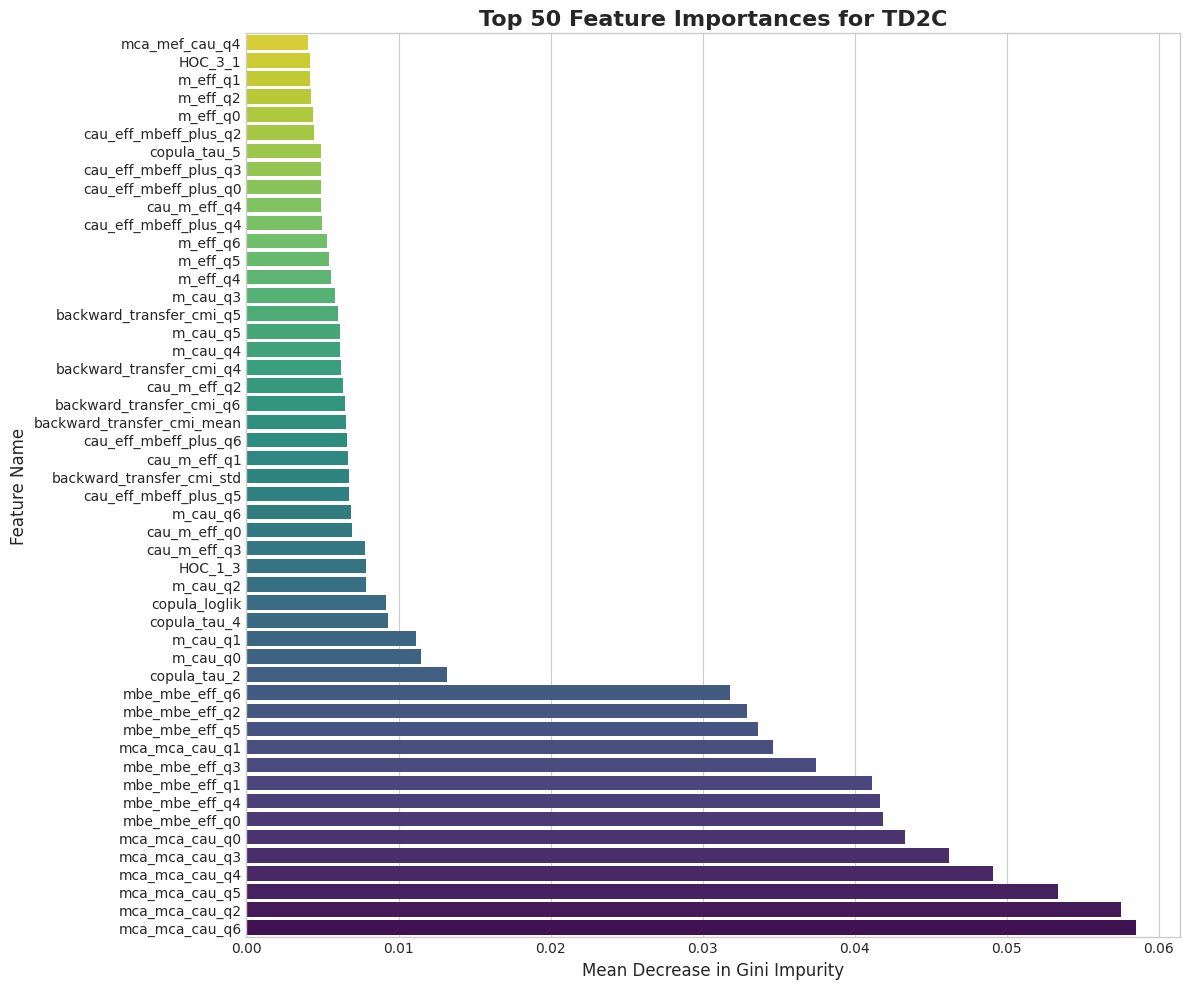

In [34]:
# feature_importance_analysis.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import roc_auc_score

# --- Configuration ---
TRAINING_DESCRIPTORS_PATH = 'data/descriptors_df_train.pkl'
TEST_DESCRIPTORS_PATH = 'data/descriptors_test.pkl' # Assuming you have a test set
FIGURE_SAVE_PATH = 'feature_importance.pdf'
N_TOP_FEATURES = 50

def feature_importance_analysis():
    """
    Trains a model on the full training data, evaluates it,
    and generates a feature importance plot.
    """
    print("--- Starting Feature Importance Analysis ---")
    
    # --- Load Data ---
    print("Loading training and testing data...")
    try:
        descriptors_df_train = pd.read_pickle(TRAINING_DESCRIPTORS_PATH)
        # Load test data to confirm model performance
        descriptors_df_test = pd.read_pickle(TEST_DESCRIPTORS_PATH)

        descriptors_df_train.fillna(descriptors_df_train.mean(), inplace=True)
        descriptors_df_test.fillna(descriptors_df_test.mean(), inplace=True)
    except FileNotFoundError as e:
        print(f"ERROR: Data file not found. {e}")
        return

    # --- Prepare Data ---
    X_train = descriptors_df_train.drop(columns=['graph_id','edge_source','edge_dest','is_causal'])
    y_train = descriptors_df_train['is_causal']
    X_test = descriptors_df_test.drop(columns=['graph_id','edge_source','edge_dest','is_causal'])
    y_test = descriptors_df_test['is_causal']
    
    # --- Train Model ---
    print("Training BalancedRandomForestClassifier on the full training set...")
    clf = BalancedRandomForestClassifier(
        n_estimators=500, 
        max_depth=None, 
        random_state=42, 
        sampling_strategy='auto',
        replacement=True,
        bootstrap=True,
        n_jobs=-1  # Use all available cores for training
    )
    clf.fit(X_train, y_train)
    
    # --- Evaluate Model Performance ---
    y_pred_proba = clf.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    print(f"Model ROC AUC on test set: {roc_auc:.4f}")
    
    # --- Get and Process Feature Importances ---
    importances = clf.feature_importances_
    feature_names = X_train.columns
    
    feature_importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values(by='importance', ascending=False)
    
    print(f"\nTop {N_TOP_FEATURES} Most Important Features:")
    print(feature_importance_df.head(N_TOP_FEATURES).to_string())

    # --- Generate Plot ---
    print(f"Generating feature importance plot for top {N_TOP_FEATURES} features...")
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(12, 10))
    
    top_features = feature_importance_df.head(N_TOP_FEATURES)
    
    sns.barplot(
        x='importance', 
        y='feature', 
        data=top_features, 
        palette='viridis', 
        ax=ax,
        orient='h'
    )
    
    ax.set_title(f'Top {N_TOP_FEATURES} Feature Importances for TD2C', fontsize=16, weight='bold')
    ax.set_xlabel('Mean Decrease in Gini Impurity', fontsize=12)
    ax.set_ylabel('Feature Name', fontsize=12)
    
    # Invert y-axis to have the most important feature on top
    ax.invert_yaxis()
    
    plt.tight_layout()
    plt.savefig(FIGURE_SAVE_PATH)
    print(f"Plot saved to {FIGURE_SAVE_PATH}")
    plt.show()

if __name__ == '__main__':
    feature_importance_analysis()

In [40]:
max_graphs

3240

In [41]:
unique_graph_ids = descriptors_df_train['graph_id'].unique()
max_graphs = len(unique_graph_ids)
print(f"Total number of graphs: {max_graphs}")

# Define training set sizes (number of graphs)
# You can adjust these ranges based on your needs
training_sizes = [1,2,3,4,5,6,7,8,9,10,15,20,25,30,35,40,45,50,100, 200, 300, 500, 1000, 1500, 2000, 2500, 3000, 3240]


# Prepare test set
X_test = descriptors_df_test.drop(columns=['graph_id','edge_source','edge_dest','is_causal'])
y_test = descriptors_df_test['is_causal']

# Storage for results
results = []

# Set random seed for reproducibility
np.random.seed(42)

for size in training_sizes:
    print(f"Training with {size} graphs...", end=' ')
    
    # Randomly select subset of graph_ids
    selected_graph_ids = np.random.choice(unique_graph_ids, size=size, replace=False)
    
    # Filter training data to only include selected graphs
    train_subset = descriptors_df_train[descriptors_df_train['graph_id'].isin(selected_graph_ids)]
    
    # Prepare training data
    X_train = train_subset.drop(columns=['graph_id','edge_source','edge_dest','is_causal'])
    y_train = train_subset['is_causal']
    
    # Train model
    clf = BalancedRandomForestClassifier(
        n_estimators=500, 
        max_depth=None, 
        random_state=0, 
        sampling_strategy='auto',
        replacement=True,
        bootstrap=True,
        n_jobs=50
    )
    clf.fit(X_train, y_train)
    
    # Make predictions on test set
    y_pred_proba = clf.predict_proba(X_test)[:, 1]  # Get probability of positive class
    
    # Calculate ROC AUC
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    # Store results
    results.append({
        'training_graphs': size,
        'training_edges': len(train_subset),
        'roc_auc': roc_auc
    })
    
    print(f"  - ROC AUC: {roc_auc:.4f}")

# Convert results to DataFrame
results_df = pd.DataFrame(results)

Total number of graphs: 3240
Training with 1 graphs...   - ROC AUC: 0.6925
Training with 2 graphs...   - ROC AUC: 0.7738
Training with 3 graphs...   - ROC AUC: 0.8350
Training with 4 graphs...   - ROC AUC: 0.8834
Training with 5 graphs...   - ROC AUC: 0.9240
Training with 6 graphs...   - ROC AUC: 0.8413
Training with 7 graphs...   - ROC AUC: 0.9029
Training with 8 graphs...   - ROC AUC: 0.9094
Training with 9 graphs...   - ROC AUC: 0.9341
Training with 10 graphs...   - ROC AUC: 0.9400
Training with 15 graphs...   - ROC AUC: 0.8588
Training with 20 graphs...   - ROC AUC: 0.9383
Training with 25 graphs...   - ROC AUC: 0.9493
Training with 30 graphs...   - ROC AUC: 0.9451
Training with 35 graphs...   - ROC AUC: 0.9593
Training with 40 graphs...   - ROC AUC: 0.9654
Training with 45 graphs...   - ROC AUC: 0.9655
Training with 50 graphs...   - ROC AUC: 0.9606
Training with 100 graphs...   - ROC AUC: 0.9681
Training with 200 graphs...   - ROC AUC: 0.9689
Training with 300 graphs...   - ROC AU


Results Summary:
    training_graphs  training_edges   roc_auc
0                 1               3  0.692474
1                 2               6  0.773813
2                 3               9  0.834975
3                 4              12  0.883409
4                 5              15  0.924017
5                 6              18  0.841342
6                 7              21  0.902855
7                 8              24  0.909411
8                 9              27  0.934058
9                10              30  0.940028
10               15              45  0.858794
11               20              60  0.938325
12               25              75  0.949342
13               30              90  0.945136
14               35             105  0.959347
15               40             120  0.965436
16               45             135  0.965474
17               50             150  0.960626
18              100             300  0.968129
19              200             600  0.968929
20              

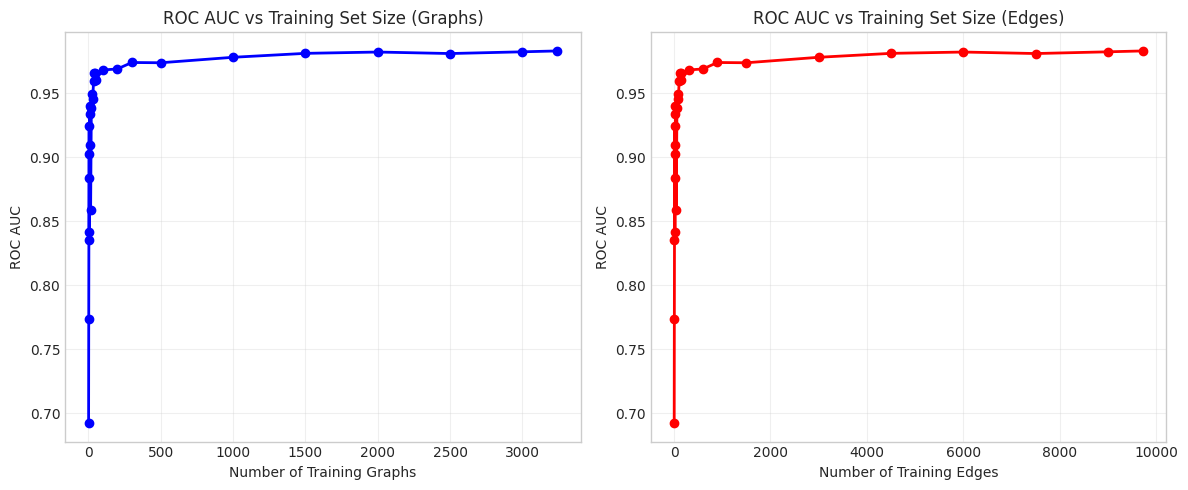


Results saved to 'training_size_analysis_results.csv'

Performance Statistics:
Best ROC AUC: 0.9830 (with 3240 graphs)
Worst ROC AUC: 0.6925 (with 1 graphs)
ROC AUC improvement: 0.2905


In [42]:
print("\nResults Summary:")
print(results_df)

# Plot results
plt.figure(figsize=(12, 5))

# Plot ROC AUC vs number of training graphs
plt.subplot(1, 2, 1)
plt.plot(results_df['training_graphs'], results_df['roc_auc'], 'b-o', linewidth=2, markersize=6)
plt.xlabel('Number of Training Graphs')
plt.ylabel('ROC AUC')
plt.title('ROC AUC vs Training Set Size (Graphs)')
plt.grid(True, alpha=0.3)

# Plot ROC AUC vs number of training edges
plt.subplot(1, 2, 2)
plt.plot(results_df['training_edges'], results_df['roc_auc'], 'r-o', linewidth=2, markersize=6)
plt.xlabel('Number of Training Edges')
plt.ylabel('ROC AUC')
plt.title('ROC AUC vs Training Set Size (Edges)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Save results
results_df.to_csv('training_size_analysis_results.csv', index=False)
print("\nResults saved to 'training_size_analysis_results.csv'")

# Print some statistics
print(f"\nPerformance Statistics:")
print(f"Best ROC AUC: {results_df['roc_auc'].max():.4f} (with {results_df.loc[results_df['roc_auc'].idxmax(), 'training_graphs']} graphs)")
print(f"Worst ROC AUC: {results_df['roc_auc'].min():.4f} (with {results_df.loc[results_df['roc_auc'].idxmin(), 'training_graphs']} graphs)")
print(f"ROC AUC improvement: {results_df['roc_auc'].max() - results_df['roc_auc'].min():.4f}")

In [43]:
# now on netsim